# Case-control analysis: SEA-AD gene-expression differences

This tutorial compares excitatory-neuron pseudo-bulk expression between disease-status groups in the [SEA-AD Middle Temporal Gyrus dataset](https://doi.org/10.1038/s41593-024-01774-5), accessed through [CellxGene Census](https://chanzuckerberg.github.io/cellxgene-census/).

The workflow is **aggregate by donor → prepare covariates → inspect factor rank → fit GCATE → estimate adjusted log-fold changes**. These are observational expression contrasts: the analysis alone establishes neither that disease causes the differences nor that the differences cause disease.

Saved results and local caches illustrate an earlier run. Recompute them when data, model settings, or the package version changes.


In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import causarray
print('causarray version:', causarray.__version__)
from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores,
)

causarray version: 0.0.10


## Why pseudo-bulk?

Disease status is measured at the donor level. Summing counts from the retained excitatory neurons gives one biological replicate per donor:

$$Y_{\mathrm{donor},g} = \sum_{\mathrm{cells\ of\ donor}}Y_{\mathrm{cell},g}.$$

`1_preprocess_sea_ad.py` combines excitatory-neuron subclasses, samples up to 300 cells per donor, sums raw counts, retains donors aged at least 60, and keeps genes whose maximum donor count exceeds 10. The cell cap is a preprocessing choice, not a general requirement of negative-binomial models.

The script codes `normal` as control and other retained disease labels as cases; inspect those labels below before describing the contrast. Aggregating across subclasses can retain differences in cell composition. Separate donor–subtype aggregates would still share donors and would not create independent biological replicates.


## Load data

In [2]:
pb = sc.read_h5ad('data/sea_ad_mtg_exneu_pb.h5ad')
pb

AnnData object with n_obs × n_vars = 85 × 22911
    obs: 'sex', 'disease', 'self_reported_ethnicity', 'development_stage', 'n_cells', 'library_size', 'age', 'trt', 'sex_bin'
    var: 'feature_name'

In [3]:
# Donor-level metadata
pb.obs[['sex', 'disease', 'trt', 'age', 'n_cells', 'library_size']].head(10)

,sex,disease,trt,age,n_cells,library_size
donor_id,,,,,,
H19.33.004,female,normal,0,80.0,300,9262925
H21.33.019,male,normal,0,75.0,300,12793728
H21.33.004,male,normal,0,80.0,300,16071238
H21.33.017,female,dementia,1,80.0,300,6558591
H20.33.041,female,dementia,1,80.0,300,11428154
H20.33.015,male,dementia,1,88.0,300,13513747
H21.33.014,male,normal,0,80.0,300,12540262
H21.33.045,female,dementia,1,80.0,300,4951466
H21.33.026,female,normal,0,80.0,300,8192575


## Exploratory data analysis

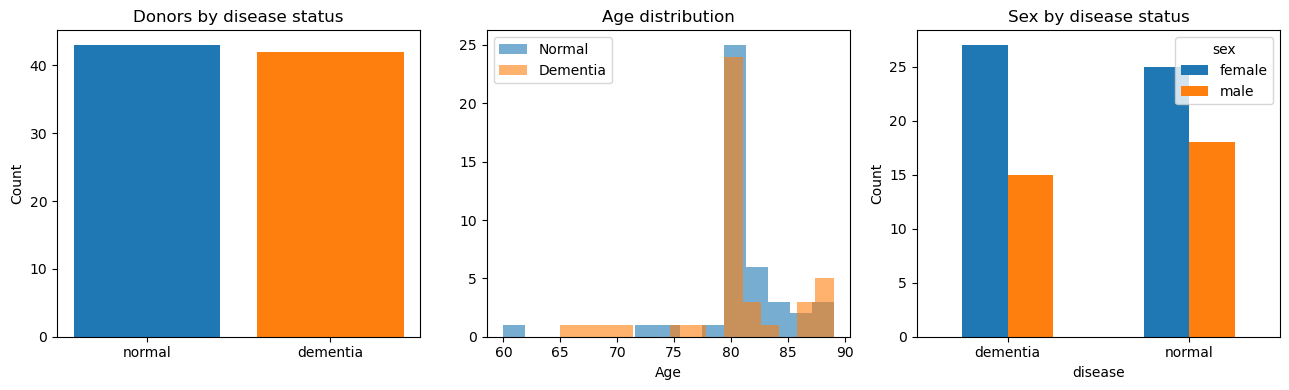

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Case / control counts
counts = pb.obs['disease'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette()[:2])
axes[0].set_title('Donors by disease status')
axes[0].set_ylabel('Count')

# Age distribution
for trt, grp in pb.obs.groupby('trt'):
    label = 'Dementia' if trt == 1 else 'Normal'
    axes[1].hist(grp['age'], bins=15, alpha=0.6, label=label)
axes[1].set_xlabel('Age')
axes[1].set_title('Age distribution')
axes[1].legend()

# Sex distribution
sex_trt = pb.obs.groupby(['disease', 'sex']).size().unstack(fill_value=0)
sex_trt.plot(kind='bar', ax=axes[2], rot=0)
axes[2].set_title('Sex by disease status')
axes[2].set_ylabel('Count')

fig.tight_layout()
plt.show()

## Prepare causarray inputs

`Y` is a donor-by-gene count matrix and `A` is a single binary disease-status column. This example includes sex as the observed adjustment covariate. Age appears in the metadata and eligibility filter but is not included in the fitted adjustment set; PMI is not included either.


In [5]:
Y = pd.DataFrame(
    pb.X.toarray() if sp.issparse(pb.X) else pb.X,
    index=pb.obs.index,
    columns=pb.var_names,
)

# Treatment: 1 = AD/dementia, 0 = normal aging
A = pb.obs[['trt']].astype(float)

# Covariate: sex (binary)
X_cov = pb.obs[['sex_bin']]

# prep_causarray_data validates shapes, adds intercept column, returns arrays
Y, A, X_cov, X_A = prep_causarray_data(Y, A, X_cov)

print(f'Donors (n): {Y.shape[0]}   Genes (p): {Y.shape[1]}')

Donors (n): 85   Genes (p): 22911


## Number of latent factors

Inspect the cached JIC table to compare candidate ranks. JIC balances fit and model complexity; it does not measure the amount of residual confounding.


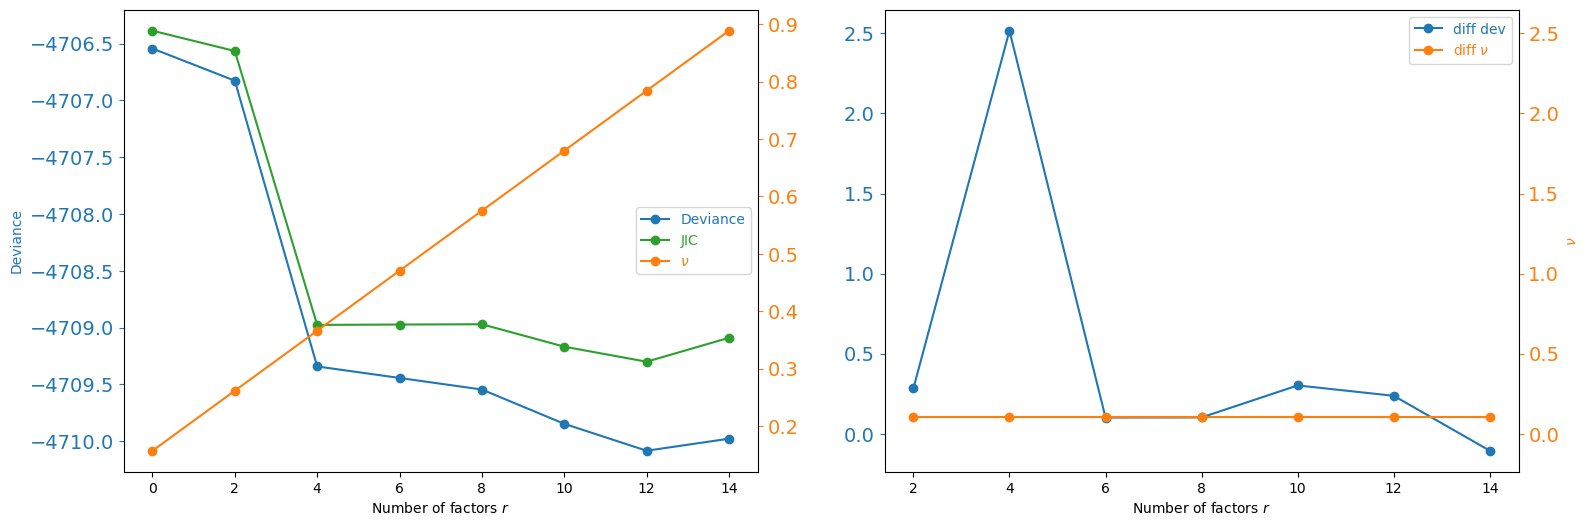

In [6]:
from causarray import estimate_r, plot_r

# Uncomment to recompute the rank-selection table:
# df_r = estimate_r(Y, X_cov, A, np.arange(2, 16, 2))
# df_r.to_csv('results/sea_ad_r.csv', index=False)
df_r = pd.read_csv('results/sea_ad_r.csv')
fig = plot_r(df_r)

The fitting cell uses an illustrative rank when no GCATE cache exists; otherwise it loads the saved fit. Inspect nearby ranks when the JIC curve is flat, and regenerate the fit cache when changing the rank or design. The loaded factor matrix determines the rank used downstream.


## Estimate latent factors with GCATE


In [7]:
import pickle

_pkl = 'results/sea_ad_gcate.pkl'
if os.path.exists(_pkl):
    print(f'Loading pre-computed GCATE from {_pkl}')
    with open(_pkl, 'rb') as f:
        res_1, res_2 = pickle.load(f)
else:
    r = 4   # Illustrative rank; inspect the JIC curve and nearby ranks.
    res_1, res_2 = fit_gcate(Y, X_cov, A, r, offset=True, verbose=True)
    with open(_pkl, 'wb') as f:
        pickle.dump((res_1, res_2), f)

U = res_2['U']
print(f'Step 1 -- epochs: {res_1["n_iter"]},  best NLL: {min(res_1["hist"]):.6f}')
print(f'Step 2 -- epochs: {res_2["n_iter"]},  best NLL: {min(res_2["hist"]):.6f}')

{'d': 3, 'n': 85, 'p': 22911, 'r': 4}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (dense, 3 columns)...'


'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (dense, 7 columns)...'


{'kwargs_es': {'max_iters': 50,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([4.15230991e+00, 1.66305561e+00, 2.20028897e+00, ...,
       1.01546418e+01, 1.00000000e+08, 1.09595567e+01]),
                'family': 'nb',
                'size_factor': array([0.93865546, 1.43671869, 1.765853  , ..., 1.19711934, 1.16245053,
       1.58667384])},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 1)...'


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:07<?, ?it/s, nll=4.58]

...

 20%|██        | 10/50 [00:03<00:06,  5.74it/s, nll=4.62]

 20%|██        | 10/50 [00:03<00:06,  5.74it/s, nll=4.62]

 20%|██        | 10/50 [00:03<00:06,  5.74it/s, Early stopped. Best Epoch: 5. Best Metric: 4.618150.]

 20%|██        | 10/50 [00:03<00:14,  2.73it/s, Early stopped. Best Epoch: 5. Best Metric: 4.618150.]

Step 1 -- epochs: 6,  best NLL: 4.584400
Step 2 -- epochs: 11,  best NLL: 4.617486


## Propensity-score diagnostics

The propensity design includes sex and the estimated latent factors. Five-fold out-of-fold logistic predictions hold each donor's disease label out of its propensity fit. The factors are still estimated from the full dataset, so the diagnostic does not validate the whole pipeline out of sample.

Read histogram overlap alongside inverse-weight ESS and prediction error. Overlap describes score distributions, while ESS detects weight concentration within each group. Neither verifies that the chosen adjustment set removes confounding.


,treatment,n_control,n_treated,prevalence,overlap_ratio,auc,brier_score,outside_overlap_fraction,clipped_fraction,ess_control,ess_treated,ess_control_fraction,ess_treated_fraction,score_q01,score_median,score_q99
0,trt,43,42,0.494118,0.608527,0.288483,0.285443,0.0,0.0,41.972006,40.897901,0.976093,0.97376,0.312448,0.483506,0.634342


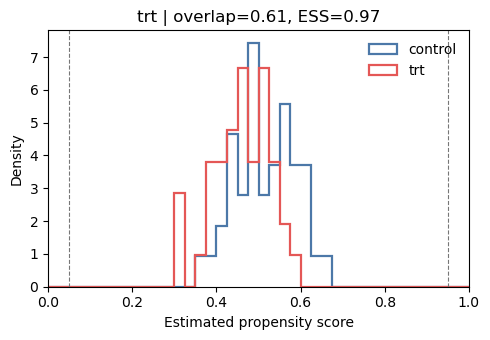

In [8]:
# Use the same observed and estimated covariates as the LFC propensity model.
W = np.c_[X_cov, U]
pi_oof = estimate_propensity_scores(A, W, K=5, random_state=0)
ps_summary = summarize_propensity_scores(A, pi_oof)
display(ps_summary)

fig, axes, _ = plot_propensity_scores(A, pi_oof, treatments=['trt'])
plt.show()

In the saved output, scores are central and both groups retain much of their nominal sample size after weighting, suggesting limited weight concentration for this fit. Prediction is weak out of sample, so these central scores should not be read as evidence that the disease groups are exchangeable.

Check predictive performance against a prevalence-only baseline, and check how much the estimates move under a different adjustment set or regularization. A smoother histogram alone is not a reason to prefer a model.


## Estimate log-fold changes

`tau` is the estimated natural-log expression ratio between the coded disease groups after adjustment for sex and latent factors, on the size-factor-normalized scale.

`LFC` uses the empirical AIPW influence-function variance, an in-sample degrees-of-freedom adjustment, a t reference, and a size-factor-aware Poisson variance floor. These corrections do not establish calibration for this dataset. Donors remain the independent units; the estimator does not account for repeated rows from the same donor.


In [9]:
# Use GCATE-internal size factors as log-scale offset (same normalization as GCATE fitting)
offsets = np.log(res_2['kwargs_glm']['size_factor'])

# Concatenate observed covariates with latent factors
W = np.c_[X_cov, U]

df_res, estimation = LFC(Y, W, A, W, offset=offsets, verbose=True)

'Estimating LFC...'
{'a': 1, 'd': 6, 'd_A': 6, 'estimands': 'LFC', 'n': 85, 'p': 22911}
{'offset': array([-0.06330679,  0.36236182,  0.56863386, ...,  0.17991812,
        0.1505303 ,  0.4616399 ]),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
{'C': 1.0,
 'class_weight': None,
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
'Fit outcome models...'
'Fitting nb GLM (structured, 6 covariates + 1 treatments)...'


'Estimating AIPW mean...'


In [10]:
# Collect results
results = df_res.copy()

n_rej_fdr = (results['padj'] < 0.1).sum()
print(f'FDR-controlled (BH, q<0.1): {n_rej_fdr}')
results.head()

FDR-controlled (BH, q<0.1): 10926


,gene_names,tau,std,log2fc,log2fc_se,stat,rej,pvalue,padj,pvalue_emp_null_adj,padj_emp_null_adj,n_treated,n_control,count_treated,count_control,mean_control,mean_treated,estimable,var_floored,std_raw
0,LINC01409,0.046102,0.039243,0.066510,0.056616,1.174768,0.0,0.243661,0.363640,0.686257,0.996942,42,43,13514.0,16076.0,327.615284,343.072410,True,False,0.039243
1,NOC2L,0.080903,0.027455,0.116718,0.039609,2.946760,0.0,0.004233,0.013569,0.305215,0.966875,42,43,4573.0,5424.0,108.234543,117.355011,True,False,0.027455
2,ENSG00000272512,-0.312502,0.208608,-0.450845,0.300958,-1.498033,0.0,0.138161,0.233562,0.590896,0.996942,42,43,88.0,149.0,3.125004,2.286298,True,False,0.208608
3,HES4,-0.611584,0.115167,-0.882329,0.166151,-5.310397,0.0,0.000001,0.000010,0.062748,0.650249,42,43,1560.0,3614.0,70.508173,38.250057,True,False,0.115167
4,ISG15,-0.355548,0.107695,-0.512947,0.155371,-3.301429,0.0,0.001453,0.005557,0.242567,0.939516,42,43,456.0,806.0,16.164352,11.327808,True,False,0.107695


## Visualise results

The volcano plot shows natural-log fold changes against nominal p-values, with color indicating the BH-adjusted threshold. The heatmap displays normalized expression for selected genes; it is descriptive and does not show covariate-adjusted residuals.


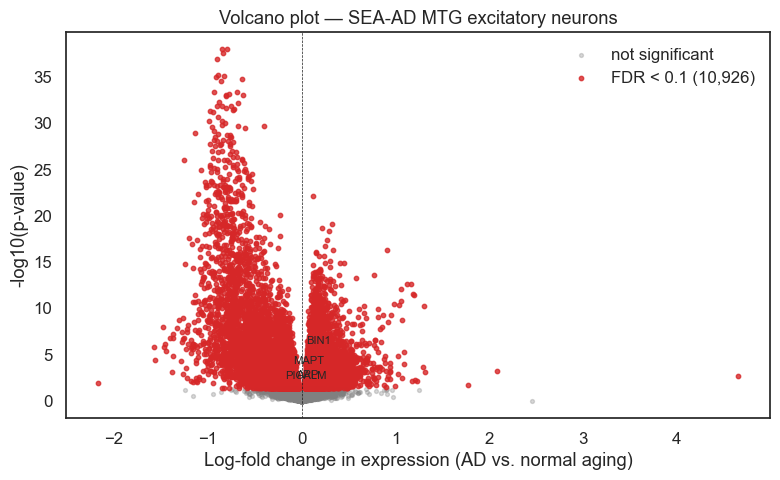

In [11]:
sns.set(font_scale=1.1, style='white')

fig, ax = plt.subplots(figsize=(8, 5))

# Colour by FDR significance
fdr_sig = results['padj'] < 0.1
ns  = results[~fdr_sig]
sig = results[fdr_sig]

ax.scatter(ns['tau'],  -np.log10(ns['pvalue']),  s=8,  alpha=0.3, color='gray',    label='not significant')
ax.scatter(sig['tau'], -np.log10(sig['pvalue']), s=10, alpha=0.8, color='tab:red', label=f'FDR < 0.1 ({len(sig):,})')

# Annotate a fixed set of example genes
annot_genes = ['BIN1', 'APP', 'MAPT', 'PICALM']
for gene in annot_genes:
    row = results[results['gene_names'] == gene]
    if len(row):
        ax.annotate(gene, xy=(row['tau'].values[0], -np.log10(row['pvalue'].values[0])),
                    fontsize=8, ha='center', va='bottom')

ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('Log-fold change in expression (AD vs. normal aging)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — SEA-AD MTG excitatory neurons')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

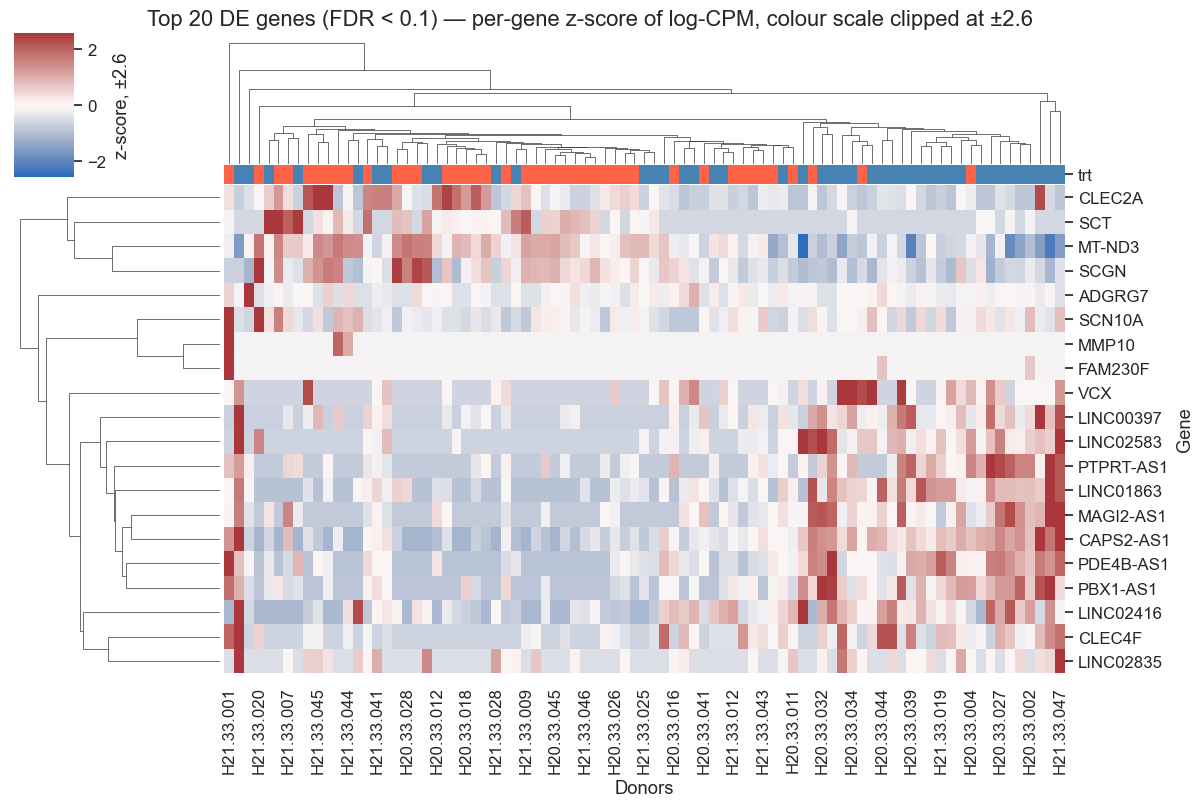

In [12]:
# Top 20 FDR-significant genes by |tau|, excluding unannotated ENSG-only entries
top_genes = (
    results[results['padj'] < 0.1]
    .assign(abs_tau=lambda d: d['tau'].abs())
    .loc[~results['gene_names'].str.startswith('ENSG')]
    .nlargest(20, 'abs_tau')['gene_names']
    .tolist()
)

if top_genes:
    X_top = pb[:, pb.var_names.isin(top_genes)].X
    if sp.issparse(X_top):
        X_top = X_top.toarray()

    # Log-CPM for display
    lib = pb.obs['library_size'].values[:, None]
    log_cpm = np.log1p(X_top / lib * 1e6)

    df_heat = pd.DataFrame(log_cpm, index=pb.obs_names,
                           columns=pb.var_names[pb.var_names.isin(top_genes)])
    row_colors = pb.obs['trt'].map({0: 'steelblue', 1: 'tomato'})

    # Standardize each gene and clip display colors at an empirical quantile.
    z_heat = (df_heat.T.sub(df_heat.T.mean(axis=1), axis=0)
                       .div(df_heat.T.std(axis=1), axis=0))
    zlim = float(np.nanquantile(z_heat.abs().values, 0.98))

    g = sns.clustermap(z_heat, col_colors=row_colors,
                       cmap='vlag', figsize=(12, 8),
                       vmin=-zlim, vmax=zlim, center=0,
                       cbar_kws={'label': f'z-score, \u00b1{zlim:.1f}'})
    g.ax_heatmap.set_xlabel('Donors')
    g.ax_heatmap.set_ylabel('Gene')
    plt.suptitle(f'Top 20 DE genes (FDR < 0.1) \u2014 per-gene z-score of log-CPM, '
                 f'colour scale clipped at \u00b1{zlim:.1f}', y=1.01)
    plt.show()
else:
    print('No genes pass the chosen threshold; inspect effect uncertainty and expression support.')

## Summary

This example adapts the workflow to donor-level disease comparisons using pseudo-bulk counts, a binary status indicator, sex, and estimated latent factors. The saved diagnostics suggest limited extreme weighting but weak propensity prediction. Interpret the gene-expression contrasts as observational associations, and check how much they move under a different adjustment set.

Gene rankings and discovery counts belong in the computed results. Biological interpretation and replication require evidence beyond this tutorial.
